In [336]:
import sys
import os
import pathlib
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
# Get the absolute path to the 'python' directory (one level up from 'notebooks')
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)


In [337]:
from Utils.FilePaths import *
import pandas as pd

data_folder = PEGEL

In [338]:
## Load files
files = list(Path.glob(data_folder, "*.csv"))
files

[PosixPath('/Users/jo/Documents/Ai_Engineering/Projects/Jo2Seb/files/data/lfs/Pegel/pegelonline-schulau-W-20000101-20260311.csv')]

In [339]:
## Load all weather data for Hamburg Fulsbüttel weather stations
df = pd.read_csv(files[0], index_col=0, sep=";")
df.index = pd.to_datetime(df.index)
df.head(5)

,value
timestamp,
2000-01-01 01:00:00,569
2000-01-01 01:01:00,568
2000-01-01 01:02:00,567
2000-01-01 01:03:00,566
2000-01-01 01:04:00,565


In [340]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 13776306 entries, 2000-01-01 01:00:00 to 2026-03-11 23:12:00
Data columns (total 1 columns):
 #   Column  Dtype
---  ------  -----
 0   value   int64
dtypes: int64(1)
memory usage: 210.2 MB


In [341]:
### Reduce measurements from hourly to minutes
df_hourly = df.resample("1h").first()   # first value of each hour^

In [342]:
df_hourly.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 229607 entries, 2000-01-01 01:00:00 to 2026-03-11 23:00:00
Freq: h
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   value   229581 non-null  float64
dtypes: float64(1)
memory usage: 3.5 MB


In [343]:
## Check for NaN values
print("Total number of values: ", len(df_hourly), \
      "\n NaN values: ", len(df_hourly.isna().sum()))


Total number of values:  229607 
 NaN values:  1


In [344]:
# Impute missing values
df_hourly =df_hourly.interpolate("linear")

file_path = data_folder / "processed_data" / "Pegel_hourly_cleaned-Schulau.csv"
df_hourly.to_csv(file_path)


In [345]:
print("number of missing values: ", df_hourly["value"].isna().sum())


number of missing values:  0


In [346]:
df_hourly_clean =  df_hourly["value"].interpolate(method="linear")
print("number of missing values: ", df_hourly_clean.isna().sum())

number of missing values:  0


In [347]:
df_hourly_clean

timestamp
2000-01-01 01:00:00    569.0
2000-01-01 02:00:00    508.0
2000-01-01 03:00:00    453.0
2000-01-01 04:00:00    407.0
2000-01-01 05:00:00    366.0
                       ...  
2026-03-11 19:00:00    640.0
2026-03-11 20:00:00    676.0
2026-03-11 21:00:00    682.0
2026-03-11 22:00:00    647.0
2026-03-11 23:00:00    588.0
Freq: h, Name: value, Length: 229607, dtype: float64

In [348]:
# Extract 1D signal from your target column

signal     = df_hourly_clean.to_numpy()
sampling_rate = 1 # 1 values per hour
N          = len(signal)
freqs      = np.fft.rfftfreq(N, d=1.0 / sampling_rate)
amplitudes = np.abs(np.fft.rfft(signal))
print("Number of freqs: ", len(freqs), "\nNumber of Amplitudes: ", len(amplitudes) )

Number of freqs:  114804 
Number of Amplitudes:  114804


In [349]:
from scipy.signal import find_peaks

# Find peaks with a minimum separation (distance in bins)
# Set distance to avoid picking neighboring bins of the same peak
peaks, properties = find_peaks(
    amplitudes[1:],       # skip DC
    distance=2000,          # minimum 50 bins apart — adjust this
    height=np.mean(amplitudes)  # optional: ignore tiny peaks below mean amplitude
)
peaks += 1  # offset back for the skipped DC bin

# Sort found peaks by amplitude descending
peaks_sorted = peaks[np.argsort(amplitudes[peaks])[::-1]]

# Print top 5 distinct peaks
print(f"{'Rank':<6} {'Frequency (1/h)':<20} {'Period (h)':<15} {'Period (days)':<15} {'Amplitude':<12}")
print("-" * 68)

rows = []
for rank, idx in enumerate(peaks_sorted[:10], 1):
   
    freq         = freqs[idx]
    period_hours = 1 / freq
    period_days  = period_hours / 24
    rows.append({
        "rank":           rank,
        "frequency_1h":   freq,
        "period_hours":   period_hours,
        "period_days":    period_days,
        "amplitude":      amplitudes[idx]
    })
    print(f"{rank:<6} {freq:<20.6f} {period_hours:<15.1f} {period_days:<15.2f} {amplitudes[idx]:<12.2f}")


Rank   Frequency (1/h)      Period (h)      Period (days)   Amplitude   
--------------------------------------------------------------------
1      0.080511             12.4            0.52            15988000.81 
2      0.038731             25.8            1.08            1017052.08  
3      0.161023             6.2             0.26            1015122.02  
4      0.000113             8831.0          367.96          684220.74   
5      0.241534             4.1             0.17            588236.57   
6      0.324755             3.1             0.13            209594.74   
7      0.119243             8.4             0.35            205302.89   
8      0.013083             76.4            3.18            178621.13   
9      0.405266             2.5             0.10            176890.68   
10     0.485778             2.1             0.09            117174.66   


In [350]:
## Save dominant frequencies
df_freqs = pd.DataFrame(rows)
file_path = data_folder / "processed_data" / "dominant_freq_analysis.csv"
df_freqs.set_index(keys="rank")
df_freqs.to_csv(file_path)

In [351]:
peaks = np.sort(peaks)[::-1][0:5]


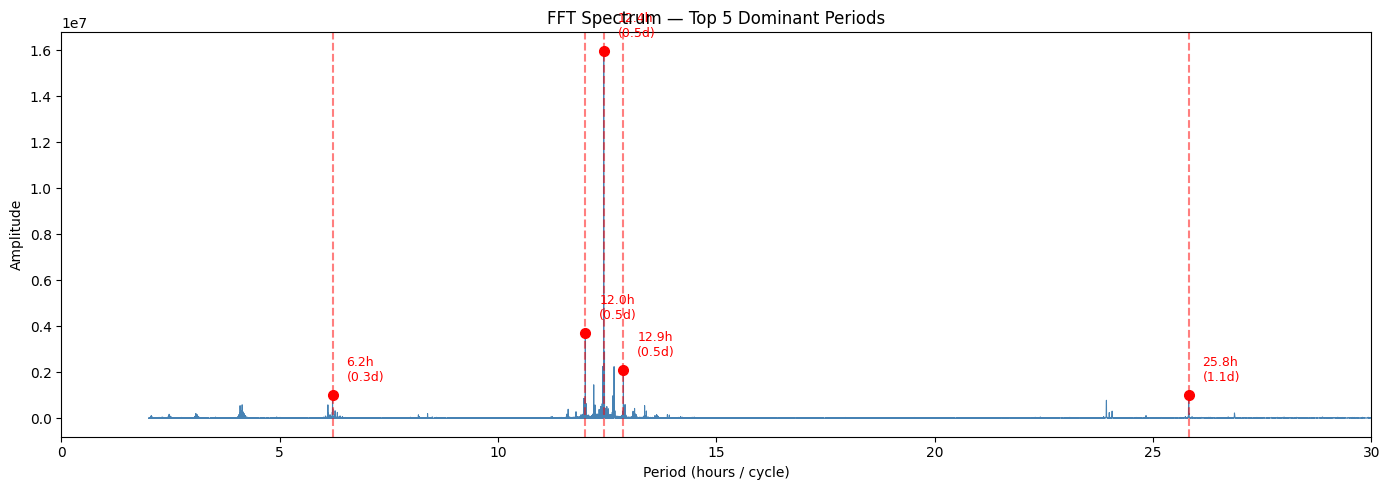

In [352]:
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Detect distinct peaks
peaks, _ = find_peaks(amplitudes[1:], distance=500, height=np.mean(amplitudes))
peaks += 1  # offset for skipped DC

# Get top 5 by amplitude
top5 = peaks[np.argsort(amplitudes[peaks])[::-1]][:5]

# Convert to period (hours/cycle), skip freq=0 to avoid division by zero
periods = 1 / freqs[1:]   # full spectrum in hours/cycle

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(periods, amplitudes[1:], lw=0.8, color='steelblue')

# Mark and label the 5 peaks
for idx in top5:
    period = 1 / freqs[idx]
    ax.axvline(period, color='red', linestyle='--', alpha=0.5)
    ax.plot(period, amplitudes[idx], 'o', color='red', markersize=7)
    ax.annotate(
        f"{period:.1f}h\n({period/24:.1f}d)",
        xy=(period, amplitudes[idx]),
        xytext=(10, 10), textcoords='offset points',
        fontsize=9, color='red'
    )

ax.set_xlabel("Period (hours / cycle)")
ax.set_ylabel("Amplitude")
#ax.set_yscale("log")
#ax.set_ylim((1e3, 1e7))
ax.set_title("FFT Spectrum — Top 5 Dominant Periods")
ax.set_xlim(0, 30)  # zoom around largest peak
plt.tight_layout()
file_path = data_folder / "graphs" / "dominant_freq_analysis.pdf"
plt.savefig(file_path)

